In [1]:
from evaluation.heuristics import calculate_hypervolume_approx, get_analytical_objectives_sample_increasing_fc
from evaluation.analytical import get_analytical_objectives
from evaluation.inference import run_experiments
from evaluation.utils import calculate_hypervolume, calculate_ordering_score
from city_env.env_model import ResourceManagementEnv
import os
from stable_baselines3 import PPO
from pymoo.util.ref_dirs import get_reference_directions
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from constants import RL_Model
import pandas as pd
from tqdm import tqdm

In [ ]:
from evaluation.stats import calculate_stats_more_objectives

calculate_stats_more_objectives(problem="logistic_long",
                                project_name="MoreObjectives",
                                total_steps=700000)

100%|██████████| 6/6 [1:12:51<00:00, 728.66s/it]


,n_obj,steps,proportion_allocated
0,5,100000,1.0000
1,5,100000,1.0000
2,5,100000,1.0000
3,5,100000,0.9925
4,5,100000,1.0000
...,...,...,...
115,20,600000,0.9995
116,20,600000,0.9935
117,20,600000,0.9595
118,20,600000,0.9615


<Figure size 640x480 with 0 Axes>

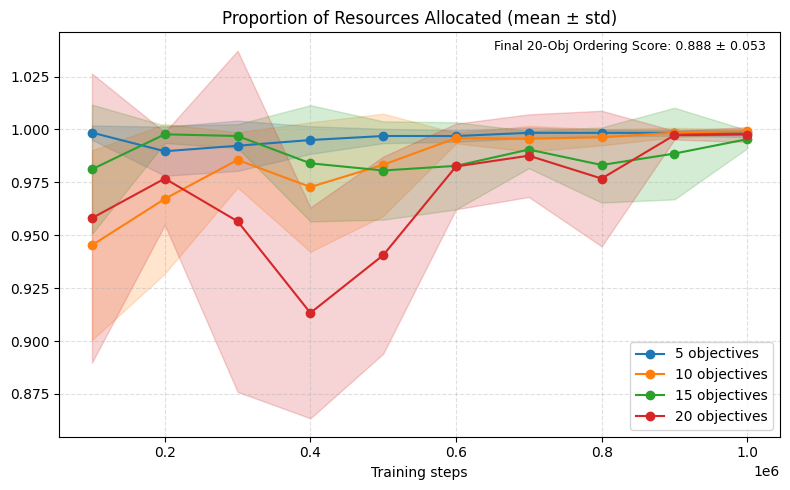

In [1]:
from evaluation.plot import plot_more_objectives

plot_more_objectives(problem="logistic_long",
                                project_name="MoreObjectives",
                                total_steps=1000000,
                                problem_display_name="Logistic Objective Function"
                                )

In [4]:
def calculate_sparse_metrics(env: ResourceManagementEnv, model = None, seed = 42):
    objectives, _ = run_experiments(env=env, model=model, n_iter = 100, random_seed=seed)
    # compute per-sample distances and reuse for stats
    distances = np.linalg.norm(objectives, axis=1)
    avg_dist = np.mean(distances)
    std_dev = np.std(distances)

    ideal_dist = np.sqrt(10 + env.n_objectives)
    distance_ratio = avg_dist / ideal_dist
    # count how many samples are (approximately) at the ideal distance
    non_dominated = np.count_nonzero(np.isclose(distances, ideal_dist)) / objectives.shape[0]
    # ordering = calculate_ordering_score(env=env, model=model)
    return {
        "distance_ratio": distance_ratio,
        "non_dominated": non_dominated,
        # "ordering": ordering
    }

def calculate_metrics(env: ResourceManagementEnv, model = None, seed = 42):
    objectives, alloc_matrices = run_experiments(env=env, model=model, n_iter = 100, random_seed=seed)

    total_unallocated = np.mean([np.sum(alloc[-1, :]) for alloc in alloc_matrices])
    # print(alloc_matrices[0])
    # print(objectives[0])
    # print(total_unallocated)

    return {
        "proportion_allocated": 1 - (total_unallocated / np.sum(env.avail_resources))
    }

100%|██████████| 16/16 [26:11<00:00, 98.19s/it] 


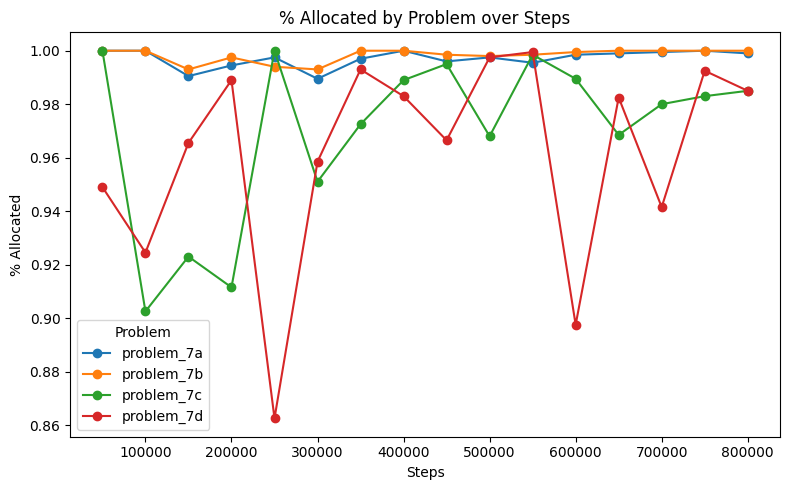

In [5]:
problems = [
    'problem_7a',
    'problem_7b',
    'problem_7c',
    'problem_7d'
]

all_metrics = []

for step in tqdm(range(50000, 800010, 50000)):
    for config_file in problems:
        model_path = f"models/test/arch-0/{config_file}/42/model_step_{step}.zip"
        model = RL_Model.load(model_path)
        env = ResourceManagementEnv(f"config/problems/{config_file}.yml")

        metrics = calculate_metrics(env=env, model=model)
        metrics['env_name'] = config_file
        metrics['steps'] = step
        all_metrics.append(metrics)


df = pd.DataFrame(all_metrics)
# sort to ensure consistent plotting order
df = df.sort_values(['env_name', 'steps'])

# pivot so each column is a problem and index is steps
dist_pivot = df.pivot_table(index='steps', columns='env_name', values='proportion_allocated')

# plot distance ratio only
fig, ax = plt.subplots(figsize=(8, 5))
dist_pivot.plot(ax=ax, marker='o')
ax.set_xlabel('Steps')
ax.set_ylabel('% Allocated')
ax.set_title('% Allocated by Problem over Steps')
ax.legend(title='Problem')

plt.tight_layout()
plt.show()


100%|██████████| 16/16 [27:06<00:00, 101.66s/it]


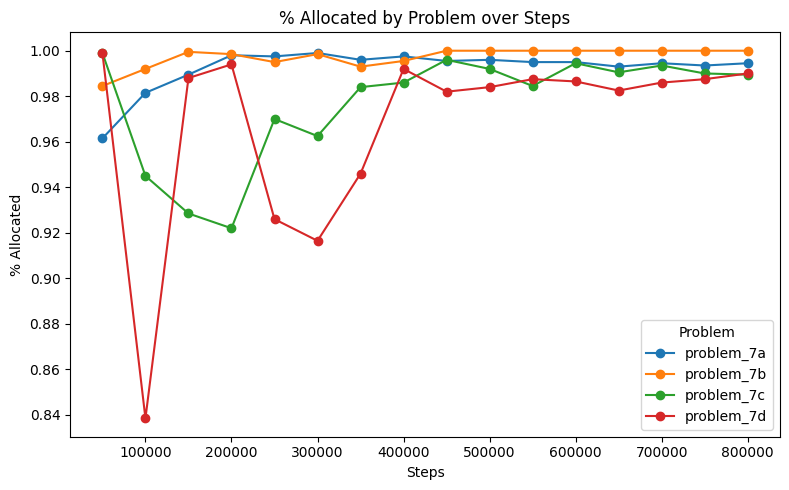

In [6]:
problems = [
    'problem_7a',
    'problem_7b',
    'problem_7c',
    'problem_7d'
]

all_metrics = []

for step in tqdm(range(50000, 800010, 50000)):
    for config_file in problems:
        model_path = f"models/test_old/arch-0/{config_file}/42/model_step_{step}.zip"
        model = RL_Model.load(model_path)
        env = ResourceManagementEnv(f"config/problems/{config_file}.yml")

        metrics = calculate_metrics(env=env, model=model)
        metrics['env_name'] = config_file
        metrics['steps'] = step
        all_metrics.append(metrics)


df = pd.DataFrame(all_metrics)
# sort to ensure consistent plotting order
df = df.sort_values(['env_name', 'steps'])

# pivot so each column is a problem and index is steps
dist_pivot = df.pivot_table(index='steps', columns='env_name', values='proportion_allocated')

# plot distance ratio only
fig, ax = plt.subplots(figsize=(8, 5))
dist_pivot.plot(ax=ax, marker='o')
ax.set_xlabel('Steps')
ax.set_ylabel('% Allocated')
ax.set_title('% Allocated by Problem over Steps')
ax.legend(title='Problem')

plt.tight_layout()
plt.show()


100%|██████████| 20/20 [27:43<00:00, 83.19s/it]



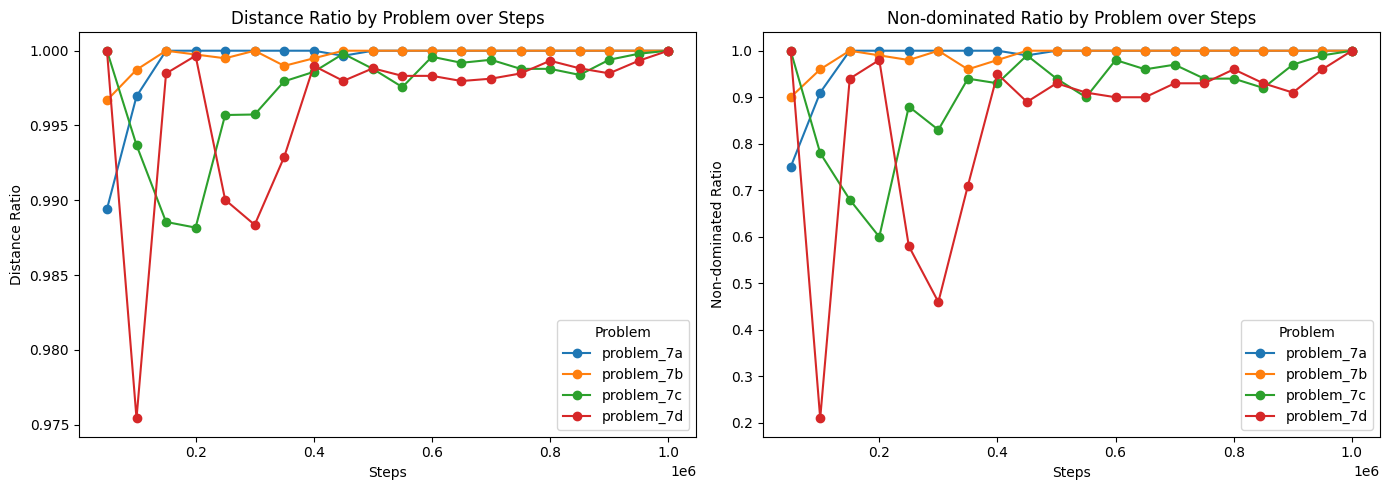

In [ ]:
problems = [
    'problem_7a',
    'problem_7b',
    'problem_7c',
    'problem_7d'
]

all_metrics = []

for step in tqdm(range(50000, 800010, 50000)):
    for config_file in problems:
        model_path = f"models/test/arch-0/{config_file}/42/model_step_{step}.zip"
        model = RL_Model.load(model_path)
        env = ResourceManagementEnv(f"config/problems/{config_file}.yml")

        metrics = calculate_sparse_metrics(env=env, model=model)
        metrics['env_name'] = config_file
        metrics['steps'] = step
        all_metrics.append(metrics)


df = pd.DataFrame(all_metrics)
# sort to ensure consistent plotting order
df = df.sort_values(['env_name', 'steps'])

# pivot so each column is a problem and index is steps
dist_pivot = df.pivot_table(index='steps', columns='env_name', values='distance_ratio')
nd_pivot = df.pivot_table(index='steps', columns='env_name', values='non_dominated')

# plot separate lines per problem on two subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

dist_pivot.plot(ax=axs[0], marker='o')
axs[0].set_xlabel('Steps')
axs[0].set_ylabel('Distance Ratio')
axs[0].set_title('Distance Ratio by Problem over Steps')
axs[0].legend(title='Problem')

nd_pivot.plot(ax=axs[1], marker='o')
axs[1].set_xlabel('Steps')
axs[1].set_ylabel('Non-dominated Ratio')
axs[1].set_title('Non-dominated Ratio by Problem over Steps')
axs[1].legend(title='Problem')

plt.tight_layout()
plt.show()


In [3]:
model_path = "models/test/arch-0/problem_7/42/model_step_1000000.zip"
model = RL_Model.load(model_path)
env = ResourceManagementEnv("config/problems/problem_7.yml")

calculate_sparse_metrics(env=env, model=model)

{'distance_ratio': np.float64(0.9999999994416172),
 'non_dominated': np.float64(1.0)}

In [5]:
model_path = "models/test/arch-0/problem_7/42/model_step_800000.zip"
model = RL_Model.load(model_path)
env = ResourceManagementEnv("config/problems/problem_7.yml")

calculate_sparse_metrics(env=env, model=model)

{'distance_ratio': np.float64(0.9993276826206898),
 'non_dominated': np.float64(0.96),
 'ordering': np.float64(0.997059557401668)}

In [2]:
category_dir = 'expand_prod_obj'

config_string = '0-1-2-0-0-1-0-4'
model_dir = f'models/{category_dir}'
env_dir = f'config/{category_dir}'
model_checkpoint = 'model_step_1000000'
n_partitions = 8

ideal_hv_list = []
ratios = []
std_devs = []
orderings = []

for idx in range(2, 12):
    problem_name = f'sqrt-p{idx}-o{idx}'
    model_path = os.path.join(model_dir, problem_name, config_string, model_checkpoint)
    env_path = os.path.join(env_dir, f"{problem_name}.yml")
    env = ResourceManagementEnv(env_path)
    model = PPO.load(model_path)
    objectives, _ = run_experiments(env=env, model=model, n_iter = 100)
    # plt.plot(objectives[:, 0], objectives[:, 1], 'o', markersize=2, label=f'N_obj = {idx}')
    
    avg_dist = np.mean(np.linalg.norm(objectives, axis=1))
    std_dev = np.std(np.linalg.norm(objectives, axis=1))

    ratios.append(avg_dist / np.sqrt(10 + env.n_objectives))
    std_devs.append(std_dev)
    orderings.append(calculate_ordering_score(env, model))
    print(f"N_obj = {idx} | Ratio = {ratios[-1]} | Std Dev = {std_devs[-1]} | Ordering = {orderings[-1]}")

N_obj = 2 | Ratio = 1.0000000045847321 | Std Dev = 5.876027616796124e-08 | Ordering = 1.0
N_obj = 3 | Ratio = 0.9968615192441437 | Std Dev = 0.03837433939565774 | Ordering = 0.9962205916608433
N_obj = 4 | Ratio = 0.9996362430395206 | Std Dev = 0.013542393534585471 | Ordering = 0.9996549079754601
N_obj = 5 | Ratio = 0.9976264265744079 | Std Dev = 0.033507420340051455 | Ordering = 0.9991683708248125
N_obj = 6 | Ratio = 0.9977772073020735 | Std Dev = 0.03240791836381862 | Ordering = 0.9997808908045978
N_obj = 7 | Ratio = 0.9924976795104202 | Std Dev = 0.06420244720678352 | Ordering = 0.997471648178924
N_obj = 8 | Ratio = 0.996593789982357 | Std Dev = 0.04913972067026491 | Ordering = 0.9988476680606881
N_obj = 9 | Ratio = 0.9959767242831902 | Std Dev = 0.050762630889379594 | Ordering = 0.9958765728933483
N_obj = 10 | Ratio = 0.9979743508348089 | Std Dev = 0.030720434184771276 | Ordering = 1.0
N_obj = 11 | Ratio = 0.9985417944571363 | Std Dev = 0.03463973327381009 | Ordering = 0.99994422755

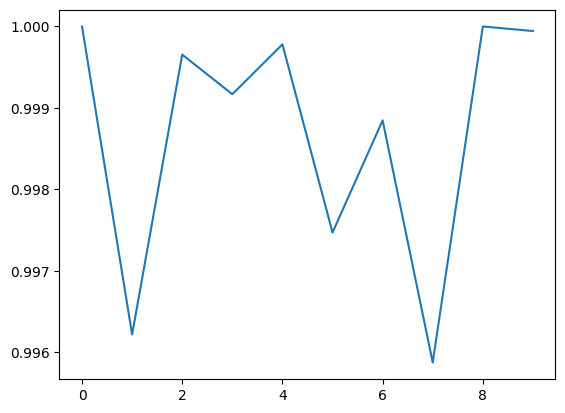

In [6]:
plt.plot(orderings)

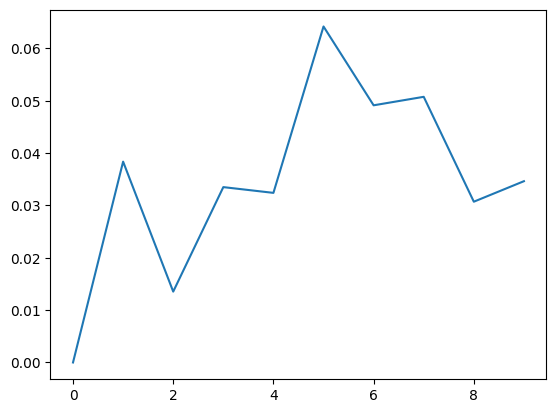

In [7]:
plt.plot(std_devs)

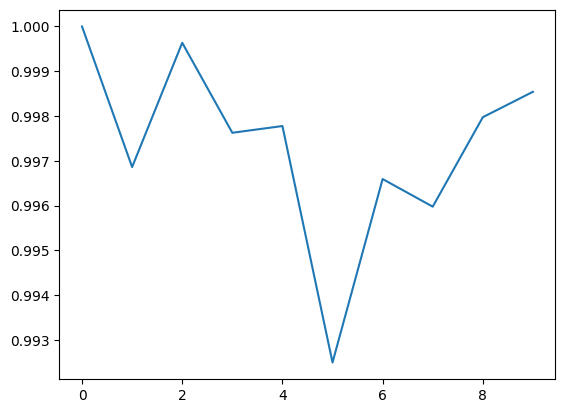

In [8]:
plt.plot(ratios)

In [ ]:
from city_env.generate_examples import expand_single_config

N = 5

expand_single_config(config_name = 'problem_7a', output_directory='problems', n_prod=N, n_objectives=N)